In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

**Goal:** Fraction of stimulus responsive neurons per region  
**Idea:** A neuron counts as responsive when its mean during the stimulus minus the mean during the habituation exceeds 2x its baseline SD

**Basic parameter settings**

In [2]:
data_dir = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected/neurons/analysis'
outdir = f'{data_dir}/responsive_neurons'
os.makedirs(outdir, exist_ok=True)

use_detrended = True
variant = 'detrended' if use_detrended else 'original'
suffix = '_detrended' if use_detrended else ''

compounds = ['control', 'PTZ', 'Tricaine']
colors = {'control': 'steelblue', 'PTZ': 'firebrick', 'Tricaine': '#7CA82A'}  # a bit darker than yellowgreen

selected_fish = {
    'control':  ['fish01', 'fish02', 'fish04', 'fish06', 'fish09'],
    'Tricaine': ['fish02', 'fish04', 'fish06', 'fish07', 'fish10'],
    'PTZ':      ['fish04', 'fish08', 'fish09', 'fish11', 'fish12'],
}

baseline_window = (90, 180)
stim_windows = {'stimulus_1': (185, 370), 'stimulus_2': (647, 832)}

responsive_k = 2.0   # threshold in units of the neuron's own baseline SD
min_baseline_sd = 1e-6   # neurons with zero baseline variance should be excluded
min_neurons_per_region = 10   # a fish's region % is NaN below this many member neurons

divisions = {'Telencephalon': 'Telencephalon -', 'Diencephalon': 'Diencephalon -',
             'Mesencephalon': 'Mesencephalon -', 'Rhombencephalon': 'Rhombencephalon -'}

**Load per-neuron data**

In [3]:
# dff is huge, read only the needed frame columns
# returns the dF/F windows, the boolean region membership, the whole-division mask membership and zbrain coordinates

def load_fish(fish, compound):
    dff_csv = f'{data_dir}/{fish}_{compound}_dFF_included_regions_zbrain{suffix}.csv'
    cells_csv = f'{data_dir}/{fish}_{compound}_cells_included_regions_zbrain.csv'

    needed = set()
    for a, b in list(stim_windows.values()) + [baseline_window]:
        needed |= {str(i) for i in range(a, b)}
    dff = pd.read_csv(dff_csv, index_col=0,
                      usecols=lambda c: str(c).startswith('Unnamed') or (c in needed))

    cells = pd.read_csv(cells_csv, index_col=0)
    if len(dff.index.difference(cells.index)):
        raise ValueError(f'{fish} {compound}: dFF and cells files index different neurons')
    cells = cells.reindex(dff.index)

    region_cols = [c for c in cells.columns if cells[c].dtype == bool]
    regions = cells[region_cols].fillna(False).astype(bool)
    division_membership = regions[list(divisions.values())].rename(
        columns={v: k for k, v in divisions.items()})
    coords = cells[['x', 'y', 'z']].astype(float)

    dff_win = {name: dff[[str(i) for i in range(a, b)]].to_numpy(np.float32)
               for name, (a, b) in stim_windows.items()}
    dff_win['baseline'] = dff[[str(i) for i in range(*baseline_window)]].to_numpy(np.float32)
    
    return dff_win, regions, division_membership, coords
    

**Per-neuron responsiveness**

In [4]:
# per neuron and stimulation phase

def neuron_responsiveness(dff_win):
    
    base = dff_win['baseline']
    base_mean = base.mean(axis=1)
    base_sd = base.std(axis=1)
    valid = base_sd > min_baseline_sd
    threshold = responsive_k * base_sd

    result = {}
    for name in stim_windows:
        amp = dff_win[name].mean(axis=1) - base_mean
        up = valid & (amp > threshold)
        down = valid & (amp < -threshold)
        result[name] = {'up': up, 'down': down, 'resp': up | down, 'amp': amp}
    return result

**Percentage of responsive neurons per region**

In [5]:
# % of member neurons with flag True per group, plus the member counts

def percent_by_group(flag, membership):
    M = membership.to_numpy(bool)
    n = M.sum(axis=0).astype(float)
    counts = flag.astype(float) @ M
    with np.errstate(invalid='ignore', divide='ignore'):
        pct = 100.0 * counts / n
    return pd.Series(pct, index=membership.columns), pd.Series(n, index=membership.columns)
    

In [6]:
def responsive_rows(responsiveness, membership, compound, fish):
    rows = []
    for event, r in responsiveness.items():
        pct_resp, n = percent_by_group(r['resp'], membership)
        pct_up = percent_by_group(r['up'], membership)[0]
        pct_down = percent_by_group(r['down'], membership)[0]
        for group in membership.columns:
            enough = int(n[group]) >= min_neurons_per_region
            rows.append({'compound': compound, 'fish': fish, 'group': group,
                         'major': group.split(' - ')[0].strip(), 'event': event,
                         'pct_resp': pct_resp[group] if enough else np.nan,
                         'pct_up': pct_up[group] if enough else np.nan,
                         'pct_down': pct_down[group] if enough else np.nan,
                         'n_neurons': int(n[group])})
    return rows

**Coordinates of responsive neurons**

In [7]:
# needed for the brain maps

def responsive_neuron_dots(dff_win, responsiveness, coords, compound, fish):
    events = list(stim_windows)
    resp = np.vstack([responsiveness[e]['resp'] for e in events]).any(axis=0)
    amp = np.vstack([responsiveness[e]['amp'] for e in events]).mean(axis=0)
    base_sd = dff_win['baseline'].std(axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        resp_z = np.where(base_sd > min_baseline_sd, amp / base_sd, 0.0)

    dots = pd.DataFrame({'fish': fish, 'compound': compound,
                         'x': coords['x'].to_numpy(), 'y': coords['y'].to_numpy(),
                         'z': coords['z'].to_numpy(),
                         'amp': amp, 'resp_z': resp_z, 'resp': resp})
    dots = dots[dots['resp'] & dots[['x', 'y', 'z']].notna().all(axis=1)].copy()
    dots['up'] = dots['amp'] > 0
    dots['down'] = ~dots['up']
    
    return dots.drop(columns='resp')

**Analyze all fish**

In [8]:
def analyze_all():
    region_rows, division_rows, dot_parts = [], [], []
    for compound in compounds:
        for fish in selected_fish[compound]:
            print(f'  {compound:8s} {fish} ...', flush=True)
            dff_win, regions, division_membership, coords = load_fish(fish, compound)
            responsiveness = neuron_responsiveness(dff_win)
            region_rows.extend(responsive_rows(responsiveness, regions, compound, fish))
            division_rows.extend(responsive_rows(responsiveness, division_membership,
                                                 compound, fish))
            dot_parts.append(responsive_neuron_dots(dff_win, responsiveness, coords,
                                                    compound, fish))
            del dff_win
            
    return (pd.DataFrame(region_rows), pd.DataFrame(division_rows),
            pd.concat(dot_parts, ignore_index=True))
    

In [9]:
# average the two stimulation for each compound, fish and group
def average_events(tbl):
    agg = (tbl.groupby(['compound', 'fish', 'group'], as_index=False)
              .agg(pct_resp=('pct_resp', 'mean'), pct_up=('pct_up', 'mean'),
                   pct_down=('pct_down', 'mean'), n_neurons=('n_neurons', 'first')))
    agg['major'] = agg['group'].str.split(' - ').str[0].str.strip()
    return agg

**Bootstrap Summary across fish**

In [10]:
# resample fish with replacement

def bootstrap_ci(values, n_boot=10000, ci=95, seed=0):
    
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    
    return float(v.mean()), float(lo), float(hi)
    

In [11]:
# mean, bootstrap CI, SD, CV over the 5 fish per compound

def group_summary(per_fish, metrics=('pct_resp', 'pct_up', 'pct_down')):
    rows = []
    
    for (compound, group), g in per_fish.groupby(['compound', 'group']):
        rec = {'compound': compound, 'group': group,
               'major': group.split(' - ')[0].strip(),
               'n_fish': int(g['pct_resp'].notna().sum())}
        for m in metrics:
            v = g[m].to_numpy(float)
            v = v[~np.isnan(v)]
            mean, lo, hi = bootstrap_ci(v)
            sd = float(np.std(v, ddof=1)) if v.size > 1 else np.nan
            rec[f'{m}_mean'] = mean
            rec[f'{m}_lo'] = lo
            rec[f'{m}_hi'] = hi
            rec[f'{m}_sd'] = sd
            rec[f'{m}_cv'] = (sd / mean) if (mean and np.isfinite(mean)) else np.nan
        rows.append(rec)
        
    return pd.DataFrame(rows)

**Plotting**

In [12]:
# grouped bar chart

def plot_responsive_by_division(per_fish_division, metric='pct_resp', ylabel=None,
                                path_to_save=None):

    rng = np.random.default_rng(0)
    division_names = list(divisions)
    fig, ax = plt.subplots(figsize=(1.6 * len(division_names) + 2, 4.2))
    width = 0.25
    
    for ci, compound in enumerate(compounds):
        for di, division in enumerate(division_names):
            v = per_fish_division[(per_fish_division.compound == compound) &
                                  (per_fish_division.group == division)][metric].to_numpy(float)
            v = v[~np.isnan(v)]
            x = di + (ci - 1) * width
            mean, lo, hi = bootstrap_ci(v)
            ax.bar(x, mean, width=width, color=colors[compound], alpha=0.85,
                   label=compound if di == 0 else None)
            ax.errorbar(x, mean, yerr=[[mean - lo], [hi - mean]], fmt='none', ecolor='k',
                        capsize=3, lw=1)
            ax.scatter(x + rng.uniform(-0.05, 0.05, v.size), v, color='k', s=12,
                       alpha=0.6, zorder=3)
            
    ax.set_xticks(range(len(division_names)))
    ax.set_xticklabels(division_names, rotation=20, ha='right')
    ax.set_ylabel(ylabel or '% responsive neurons', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    # ax.set_title('Responsive neurons per division', fontsize=14)
    ax.legend(frameon=False, fontsize=12)
    fig.tight_layout()
    
    if path_to_save:
        fig.savefig(path_to_save, bbox_inches='tight')
        
    return fig, ax

In [13]:
# bar chart with up-responders plotted positive and down-responders negative

def plot_updown_by_division(per_fish_division, path_to_save=None):

    rng = np.random.default_rng(1)
    division_names = list(divisions)
    fig, axs = plt.subplots(1, len(division_names), figsize=(2.6 * len(division_names), 4.2),
                            sharey=True)
    
    for ax, division in zip(axs, division_names):
        for ci, compound in enumerate(compounds):
            sub = per_fish_division[(per_fish_division.compound == compound) &
                                    (per_fish_division.group == division)]
            up = sub['pct_up'].to_numpy(float); up = up[~np.isnan(up)]
            down = sub['pct_down'].to_numpy(float); down = down[~np.isnan(down)]
            ax.bar(ci, np.nanmean(up), color=colors[compound], alpha=0.85)
            ax.bar(ci, -np.nanmean(down), color=colors[compound], alpha=0.45)
            ax.scatter(ci + rng.uniform(-0.05, 0.05, up.size), up, color='k', s=10, alpha=0.6)
            ax.scatter(ci + rng.uniform(-0.05, 0.05, down.size), -down, color='k', s=10,
                       alpha=0.6)
            
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(range(len(compounds)))
        ax.set_xticklabels(compounds, rotation=20, ha='right')
        ax.tick_params(axis='both', labelsize=12)
        ax.set_title(division, fontsize=12)
        
    axs[0].set_ylabel('% down  versus  % up', fontsize=14)
    # fig.suptitle('Up- vs down-responders per division', y=1.02, fontsize=14)
    fig.tight_layout()
    
    if path_to_save:
        fig.savefig(path_to_save, bbox_inches='tight')
        
    return fig, axs

In [14]:
def plot_heatmap(summary_division, metric='pct_resp_mean', path_to_save=None):

    division_names = list(divisions)
    H = np.array([[summary_division[(summary_division.compound == c) &
                                    (summary_division.group == d)][metric].mean()
                   for c in compounds] for d in division_names])
    
    fig, ax = plt.subplots(figsize=(1.1 * len(compounds) + 1.5, 0.6 * len(division_names) + 1.5))
    im = ax.imshow(H, cmap='magma', aspect='auto')
    ax.set_xticks(range(len(compounds))); ax.set_xticklabels(compounds)
    ax.set_yticks(range(len(division_names))); ax.set_yticklabels(division_names)
    
    for i in range(len(division_names)):
        for j in range(len(compounds)):
            ax.text(j, i, f'{H[i, j]:.0f}', ha='center', va='center',
                    color='w' if H[i, j] < np.nanmax(H) * 0.6 else 'k', fontsize=9)
            
    fig.colorbar(im, ax=ax, label='% responsive')
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title('% responsive', fontsize=14)
    fig.tight_layout()
    
    if path_to_save:
        fig.savefig(path_to_save, bbox_inches='tight')
        
    return fig, ax

**Run analysis and save results as csv files**

In [15]:
tbl_region, tbl_division, neurons = analyze_all()
per_fish_region = average_events(tbl_region)
per_fish_division = average_events(tbl_division)

tbl_region.to_csv(f'{outdir}/responsive_per_event_region_{variant}.csv', index=False)
per_fish_region.to_csv(f'{outdir}/responsive_per_fish_region_{variant}.csv', index=False)
tbl_division.to_csv(f'{outdir}/responsive_per_event_division_{variant}.csv', index=False)
per_fish_division.to_csv(f'{outdir}/responsive_per_fish_division_{variant}.csv', index=False)
neurons.to_csv(f'{outdir}/responsive_per_neuron_{variant}.csv', index=False)

per_fish_division.head()

  control  fish01 ...
  control  fish02 ...
  control  fish04 ...
  control  fish06 ...
  control  fish09 ...
  PTZ      fish04 ...
  PTZ      fish08 ...
  PTZ      fish09 ...
  PTZ      fish11 ...
  PTZ      fish12 ...
  Tricaine fish02 ...
  Tricaine fish04 ...
  Tricaine fish06 ...
  Tricaine fish07 ...
  Tricaine fish10 ...


,compound,fish,group,pct_resp,pct_up,pct_down,n_neurons,major
0,PTZ,fish04,Diencephalon,61.811371,55.597179,6.214191,2269,Diencephalon
1,PTZ,fish04,Mesencephalon,57.745399,52.035158,5.710241,8476,Mesencephalon
2,PTZ,fish04,Rhombencephalon,45.770791,37.450980,8.319811,14790,Rhombencephalon
3,PTZ,fish04,Telencephalon,43.548387,39.193548,4.354839,1860,Telencephalon
4,PTZ,fish08,Diencephalon,84.461054,79.674797,4.786258,3813,Diencephalon


**Percent responsive neurons per division**

(<Figure size 840x420 with 1 Axes>, <Axes: ylabel='% responsive neurons'>)

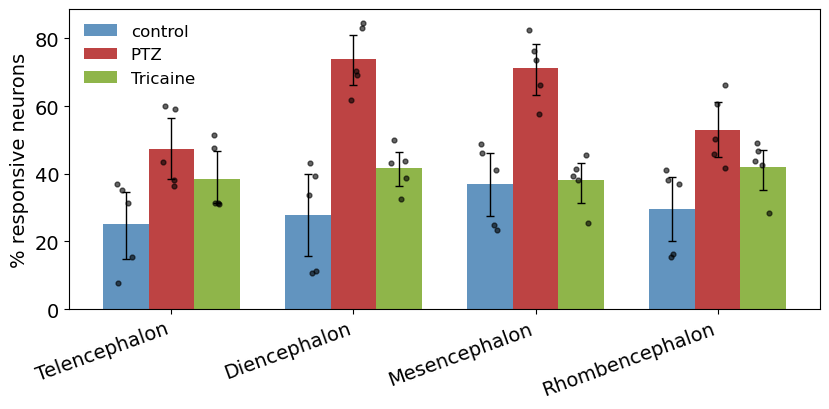

In [16]:
plot_responsive_by_division(per_fish_division, 'pct_resp',
                            path_to_save=f'{outdir}/pct_responsive_by_division_{variant}.pdf')

In [17]:
per_fish_division.pivot_table(index='group', columns='compound',
                              values='pct_resp').round(1).reindex(list(divisions))

compound,PTZ,Tricaine,control
group,,,
Telencephalon,47.4,38.6,25.3
Diencephalon,73.8,41.6,27.7
Mesencephalon,71.3,38.0,36.9
Rhombencephalon,53.0,42.1,29.6


**Up versus down responders**

(<Figure size 1040x420 with 4 Axes>,
 array([<Axes: title={'center': 'Telencephalon'}, ylabel='% down  versus  % up'>,
        <Axes: title={'center': 'Diencephalon'}>,
        <Axes: title={'center': 'Mesencephalon'}>,
        <Axes: title={'center': 'Rhombencephalon'}>], dtype=object))

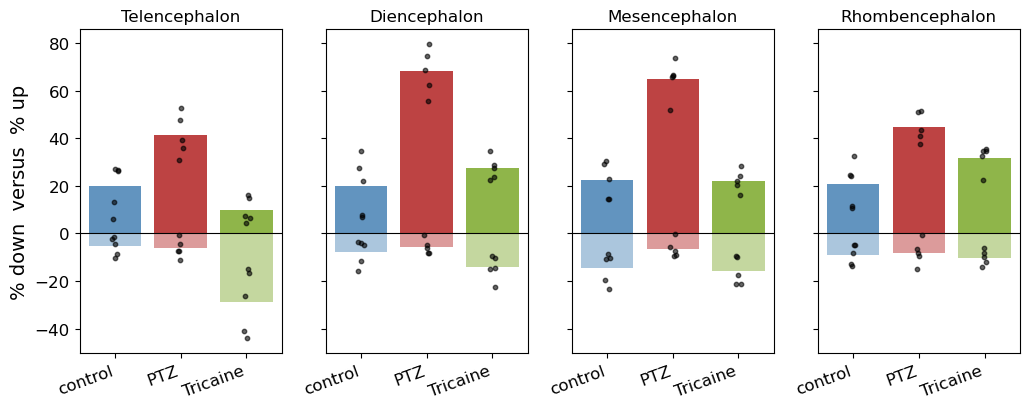

In [18]:
plot_updown_by_division(per_fish_division,
                        path_to_save=f'{outdir}/updown_by_division_{variant}.pdf')

**Group summary and heatmap**

In [19]:
summary_division = group_summary(per_fish_division)
summary_division.to_csv(f'{outdir}/responsive_summary_division_{variant}.csv', index=False)

In [20]:
summary_region = group_summary(per_fish_region)
summary_region.to_csv(f'{outdir}/responsive_summary_region_{variant}.csv', index=False)

(<Figure size 480x390 with 2 Axes>, <Axes: title={'center': '% responsive'}>)

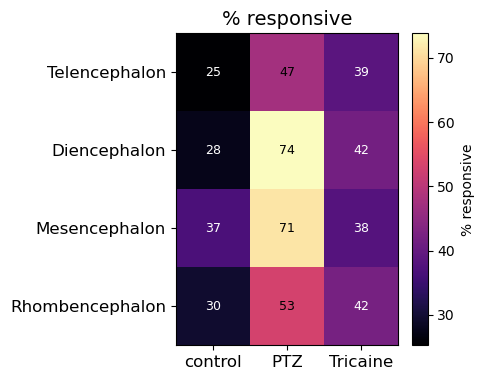

In [21]:
plot_heatmap(summary_division, 'pct_resp_mean',
             path_to_save=f'{outdir}/heatmap_division_{variant}.pdf')

In [22]:
show_cols = ['compound', 'group', 'n_fish', 'pct_resp_mean', 'pct_resp_lo', 'pct_resp_hi',
             'pct_resp_cv', 'pct_up_mean', 'pct_down_mean']
summary_division[show_cols].round(2)

,compound,group,n_fish,pct_resp_mean,pct_resp_lo,pct_resp_hi,pct_resp_cv,pct_up_mean,pct_down_mean
0,PTZ,Diencephalon,5,73.81,66.34,81.15,0.13,68.25,5.56
1,PTZ,Mesencephalon,5,71.31,63.15,78.31,0.13,64.89,6.42
2,PTZ,Rhombencephalon,5,52.96,45.06,61.10,0.19,44.96,8.00
3,PTZ,Telencephalon,5,47.44,38.53,56.36,0.24,41.27,6.18
4,Tricaine,Diencephalon,5,41.63,36.24,46.32,0.16,27.35,14.28
5,Tricaine,Mesencephalon,5,38.02,31.23,43.08,0.20,22.21,15.81
6,Tricaine,Rhombencephalon,5,42.09,35.18,47.05,0.19,31.93,10.16
7,Tricaine,Telencephalon,5,38.57,31.26,46.64,0.26,9.91,28.66
8,control,Diencephalon,5,27.68,15.59,39.78,0.56,19.77,7.91
9,control,Mesencephalon,5,36.87,27.56,46.19,0.32,22.36,14.51
